In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Load and Inspect the Dataset

In [55]:
df=pd.read_csv(r"titanic (1).csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [56]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [58]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [59]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


# Data Cleaning

In [60]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [61]:
df.dropna(inplace=True)

In [62]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [63]:
df.duplicated().sum()

np.int64(0)

In [64]:
df.shape

(183, 12)

In [65]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

<Axes: >

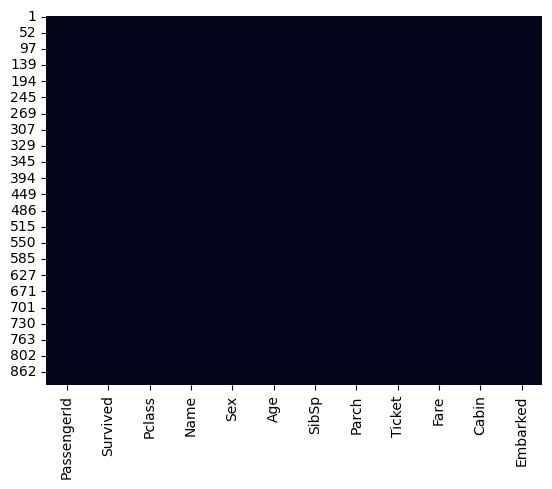

In [66]:
import seaborn as sns
sns.heatmap(df.isnull(), cbar=False)

<Axes: >

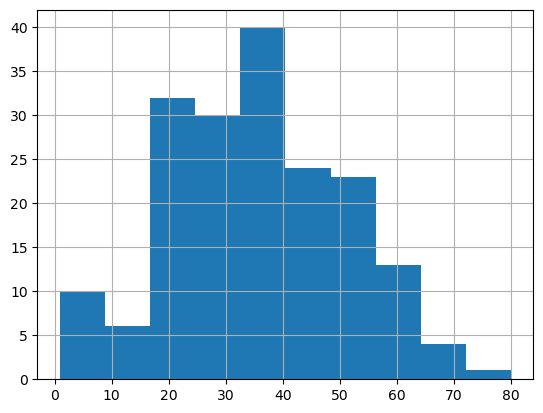

In [67]:
import matplotlib.pyplot as plt
df['Age'].hist()


In [68]:

# Convert categorical → numeric using Label Encoding (SEX)
label_enc = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = label_enc.fit_transform(df[col])

In [69]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,49,0,38.0,1,0,109,71.2833,72,0
3,4,1,1,70,0,35.0,1,0,31,53.1000,48,2
6,7,0,1,112,1,54.0,0,0,55,51.8625,117,2
10,11,1,3,148,0,4.0,1,1,120,16.7000,131,2
11,12,1,1,27,0,58.0,0,0,26,26.5500,43,2


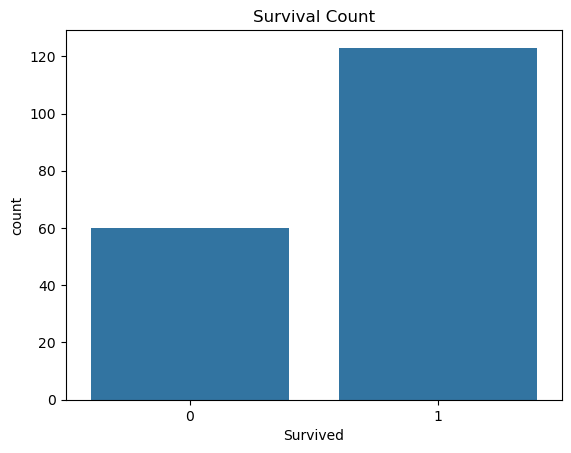

In [70]:
# Countplot for target (if 'Survived' exists)
if 'Survived' in df.columns:
    sns.countplot(data=df, x='Survived')
    plt.title("Survival Count")
    plt.show()

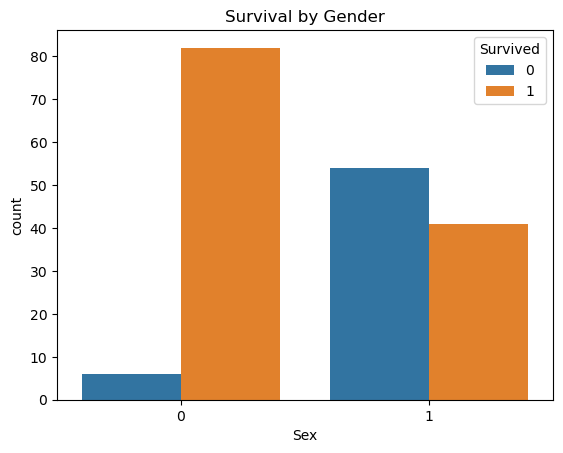

In [71]:
# Example: Survival by gender
if {'Sex', 'Survived'}.issubset(df.columns):
    sns.countplot(data=df, x='Sex', hue='Survived')
    plt.title("Survival by Gender")
    plt.show()

In [72]:
# Define features and target
X = df[['Age', 'Pclass', 'Sex']]
y = df['Survived']

In [73]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [74]:
#Applying Naive Bayes theorem
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [75]:
# Create a Gaussian Naive Bayes classifier object
clf = GaussianNB()

In [76]:
# Train the model (assuming X_train and y_train are your training data)
clf.fit(X_train, y_train)

# Make predictions (assuming X_test is your test data)
y_pred = clf.predict(X_test)

In [77]:
y_pred

array([0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1,
       0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1])

In [78]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[12  2]
 [ 6 17]]


In [79]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7837837837837838

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.86      0.75        14
           1       0.89      0.74      0.81        23

    accuracy                           0.78        37
   macro avg       0.78      0.80      0.78        37
weighted avg       0.81      0.78      0.79        37



In [80]:
#decision Tree

In [81]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize and train
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_dt = dt_model.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))



Decision Tree Accuracy: 0.7297297297297297
              precision    recall  f1-score   support

           0       0.70      0.50      0.58        14
           1       0.74      0.87      0.80        23

    accuracy                           0.73        37
   macro avg       0.72      0.68      0.69        37
weighted avg       0.73      0.73      0.72        37



from the naive bias the model got an accuracy of 0.7837837837837838 and from decision tree the accuracy reduce to 0.7297297297297297


In [84]:
#so we can apply cross validation in nayve bias 
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [86]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.naive_bayes import GaussianNB

# Example model
model = GaussianNB()

# X and y as pandas DataFrame/Series
# Example:
# X = df.drop('target', axis=1)
# y = df['target']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracies = []
conf_matrices = []

fold = 1
for train_index, test_index in skf.split(X, y):
    # ✅ Use .iloc for DataFrames
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    accuracies.append(acc)
    conf_matrices.append(cm)
    
    print(f"\n📘 Fold {fold} Results:")
    print(f"Accuracy: {acc:.4f}")
    print("Confusion Matrix:\n", cm)
    print("Classification Report:\n", classification_report(y_test, y_pred))
    fold += 1

print("\n✅ Mean Accuracy across folds:", np.mean(accuracies))



📘 Fold 1 Results:
Accuracy: 0.7568
Confusion Matrix:
 [[10  2]
 [ 7 18]]
Classification Report:
               precision    recall  f1-score   support

           0       0.59      0.83      0.69        12
           1       0.90      0.72      0.80        25

    accuracy                           0.76        37
   macro avg       0.74      0.78      0.74        37
weighted avg       0.80      0.76      0.76        37


📘 Fold 2 Results:
Accuracy: 0.7027
Confusion Matrix:
 [[10  2]
 [ 9 16]]
Classification Report:
               precision    recall  f1-score   support

           0       0.53      0.83      0.65        12
           1       0.89      0.64      0.74        25

    accuracy                           0.70        37
   macro avg       0.71      0.74      0.69        37
weighted avg       0.77      0.70      0.71        37


📘 Fold 3 Results:
Accuracy: 0.7027
Confusion Matrix:
 [[ 9  3]
 [ 8 17]]
Classification Report:
               precision    recall  f1-score   suppor

In [89]:
##so we can apply cross validation in decision tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [90]:
# Initialize Decision Tree model
model = DecisionTreeClassifier(random_state=42)


In [91]:
# Define Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# To store results
accuracies = []
conf_matrices = []
fold = 1

# Cross-validation loop
for train_index, test_index in skf.split(X, y):
    # Split data using .iloc for pandas
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Train model
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    accuracies.append(acc)
    conf_matrices.append(cm)
    
    print(f"\n📘 Fold {fold} Results:")
    print(f"Accuracy: {acc:.4f}")
    print("Confusion Matrix:\n", cm)
    print("Classification Report:\n", classification_report(y_test, y_pred))
    fold += 1

# Final Results
print("\n✅ Mean Accuracy across folds:", np.mean(accuracies))


📘 Fold 1 Results:
Accuracy: 0.7838
Confusion Matrix:
 [[ 7  5]
 [ 3 22]]
Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.58      0.64        12
           1       0.81      0.88      0.85        25

    accuracy                           0.78        37
   macro avg       0.76      0.73      0.74        37
weighted avg       0.78      0.78      0.78        37


📘 Fold 2 Results:
Accuracy: 0.7297
Confusion Matrix:
 [[ 7  5]
 [ 5 20]]
Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.58      0.58        12
           1       0.80      0.80      0.80        25

    accuracy                           0.73        37
   macro avg       0.69      0.69      0.69        37
weighted avg       0.73      0.73      0.73        37


📘 Fold 3 Results:
Accuracy: 0.7568
Confusion Matrix:
 [[10  2]
 [ 7 18]]
Classification Report:
               precision    recall  f1-score   suppor

In [92]:
#we can  conclude that naive bias theorem has high accuracy